# Why was one system picked over the other? — Feedback-text analysis

Human evaluators compared two systems on scientific (gut-microbiome) questions — **Eubiota**, a
multi-agent *deep-research* system (labelled `agent`), versus a **general chatbot** (`llm`) — and for
each comparison wrote a short **free-text reason** for their choice. This notebook analyses that
reasoning: *what makes people prefer one system over the other?*

**Data (two ANONYMOUS batches only).** We read **only** the `ANONYMOUS ` files (the de-identified
exports); the non-anonymous copies are ignored. `Actual Winner` gives the chosen system
(`agent` / `llm` / `tie`); the free text is the reviewer's justification.

**One property that shapes the analysis:** many reviewers picked from a small set of **preset
reasons**, so the ~285 usable comments collapse to **86 unique strings** (some presets recur 20–40×).
We report the *weighted* view (every evaluation counts) as the primary lens, and use the unique
strings for embeddings. **Ties are kept** in the data figures and excluded only from the
Eubiota-vs-chatbot theme comparisons.

All figures share one muted colour scheme (**Eubiota = blue, Chatbot = gold**) and are **SVG** with
**Arial** text.

## 0. Configuration & a refined publication style

In [1]:
import os
from pathlib import Path
# Fig 9 uses a cached embedding model. Skip the HuggingFace update-check (which can stall) when the
# model is already cached; on a fresh machine (e.g. your boss cloning this), leave the network ON so
# it downloads once (~80 MB) instead of erroring.  cached -> offline & instant; not cached -> 1x download.
if (Path.home() / ".cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2").exists():
    os.environ["HF_HUB_OFFLINE"] = "1"; os.environ["TRANSFORMERS_OFFLINE"] = "1"
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

DATA = Path("data"); FIG = Path("figures"); FIG.mkdir(exist_ok=True)
RNG = np.random.default_rng(20240716); N_BOOT = 5000

# ---- only the ANONYMOUS de-identified files are ever read ----
SRC = {"current":  DATA / "ANONYMOUS Human study results_revision - current data.csv",
       "previous": DATA / "ANONYMOUS Human study results_revision - Previous data.csv"}
for p in SRC.values():
    assert p.exists() and "ANONYMOUS" in p.name, f"refusing non-anonymous / missing file: {p.name}"
print("reading anonymous files:", [p.name for p in SRC.values()])

# ---- palette: two base hues + tints/shades, all harmonised ----
EUB,  LLM,  TIE  = "#4C72B0", "#E0B63E", "#BFC4CB"     # base
EUB_D, LLM_D     = "#33517F", "#A9821B"                # shades (labels/emphasis)
EUB_L, LLM_L     = "#AFC3E0", "#F0DDA0"                # tints (soft fills)
INK, MUTE, HAIR  = "#22262B", "#7B828A", "#E9ECEF"     # text / secondary / hairline
NEUTRAL_L, NEUTRAL_D = "#DBDFE4", "#8B929A"
SYS_COLORS = {"agent": EUB, "llm": LLM, "tie": TIE}
SYS_SHADE  = {"agent": EUB_D, "llm": LLM_D}
SYS_LABEL  = {"agent": "Eubiota (agent)", "llm": "Chatbot (LLM)", "tie": "Tie"}
BATCH_ORDER = ["previous", "current"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#FFFFFF", "#E7EEF6", EUB, "#2C466E"])

mpl.rcParams.update({
    "svg.fonttype": "none", "font.family": "Arial", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12, "axes.titlecolor": INK,
    "axes.labelsize": 10.5, "axes.labelcolor": "#41474D", "axes.labelpad": 7,
    "axes.edgecolor": "#CBD0D6", "axes.linewidth": 1.1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": "#EEF0F3", "grid.linewidth": 1.1,
    "xtick.color": "#5B636B", "ytick.color": "#5B636B", "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5, "legend.frameon": False,
    "figure.dpi": 150, "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.bbox": "tight",
})

def polish(ax, left=True, bottom=True, grid="y"):
    ax.spines["left"].set_visible(left); ax.spines["bottom"].set_visible(bottom)
    for s in ("left", "bottom"): ax.spines[s].set_color("#CBD0D6")
    ax.tick_params(length=0)
    ax.grid(grid == "y", axis="y"); ax.grid(grid == "x", axis="x"); ax.set_axisbelow(True)
    return ax

def titles(ax, text):
    ax.set_title(text, loc="left")

def zebra(ax, n):
    """Soft alternating row bands behind horizontal categorical charts."""
    for i in range(0, n, 2):
        ax.axhspan(i-0.5, i+0.5, color="#F6F7F9", zorder=0, lw=0)

def panel(ax, letter):
    ax.text(-0.015, 1.10, letter, transform=ax.transAxes, fontsize=15, fontweight="bold",
            color=INK, ha="right", va="bottom")

def savefig(fig, name):
    out = FIG / f"{name}.svg"; fig.savefig(out); print("saved", out); return out

THEME_LABEL = {
    "citation_evidence": "Citations / evidence", "transparency_trace": "Transparency / trace",
    "detail_thoroughness": "Detail / thoroughness", "specificity": "Specificity",
    "conciseness_directness": "Conciseness / directness", "clarity_structure": "Clarity / structure",
    "accuracy_correctness": "Accuracy / correctness", "actionability": "Actionability / usefulness",
    "unsupported_speculative": "Unsupported / speculative", "retrieval_tool_failure": "Retrieval / tool failure",
}
THEMES_ORDER = list(THEME_LABEL.keys())

reading anonymous files: ['ANONYMOUS Human study results_revision - current data.csv', 'ANONYMOUS Human study results_revision - Previous data.csv']


## 1. Build the unified corpus

Both batches are read, the free-text reason is extracted (in the current batch it may follow a
`General Feedback:` rubric string; in the previous batch it is the `Comment`), and rows are marked
*usable* if the comment is substantive (not blank or "-"). **Ties are kept.**

In [2]:
def extract_current(t):
    t = str(t); m = re.search(r"General Feedback:\s*(.*)", t, re.S | re.I)
    return (m.group(1) if m else t).strip()

cur = pd.read_csv(SRC["current"]); prev = pd.read_csv(SRC["previous"])
cur_t = pd.DataFrame({"batch": "current", "query": cur["Query"], "user_selected": cur["User Selected"],
                      "system": cur["Actual Winner"], "feedback": cur["Unnamed: 4"].apply(extract_current)})
prev_t = pd.DataFrame({"batch": "previous", "query": prev["Query"], "user_selected": prev["User Selected"],
                       "system": prev["Actual Winner"], "feedback": prev["Comment"].astype(str).str.strip()})
corpus = pd.concat([cur_t, prev_t], ignore_index=True)
corpus["feedback"] = corpus["feedback"].fillna("").astype(str)
corpus["usable"] = (corpus["feedback"].str.len() > 3) & (corpus["feedback"] != "-") & (corpus["feedback"].str.lower() != "nan")
corpus["n_words"] = corpus["feedback"].str.split().apply(len)
corpus.to_csv(DATA / "feedback_corpus_tidy.csv", index=False)

print("rows:", len(corpus), "| by batch:", corpus.groupby("batch").size().to_dict())
print("by winner system:", corpus["system"].value_counts(dropna=False).to_dict())
print("usable feedback:", int(corpus["usable"].sum()), "| ties kept:", int((corpus.system == "tie").sum()))
AL = corpus[corpus.usable & corpus.system.isin(["agent", "llm"])].copy()
print("usable agent/llm rows (theme analysis):", len(AL), "| unique comments:", AL["feedback"].nunique())

rows: 383 | by batch: {'current': 255, 'previous': 128}
by winner system: {'agent': 286, 'llm': 92, 'tie': 5}
usable feedback: 285 | ties kept: 5
usable agent/llm rows (theme analysis): 284 | unique comments: 86


### Figure 1 — Dataset flow
*How the raw rows narrow to the analysable set, and how the wins split by system, in each batch (ties kept).*

saved figures/fig1_dataset_flow.svg


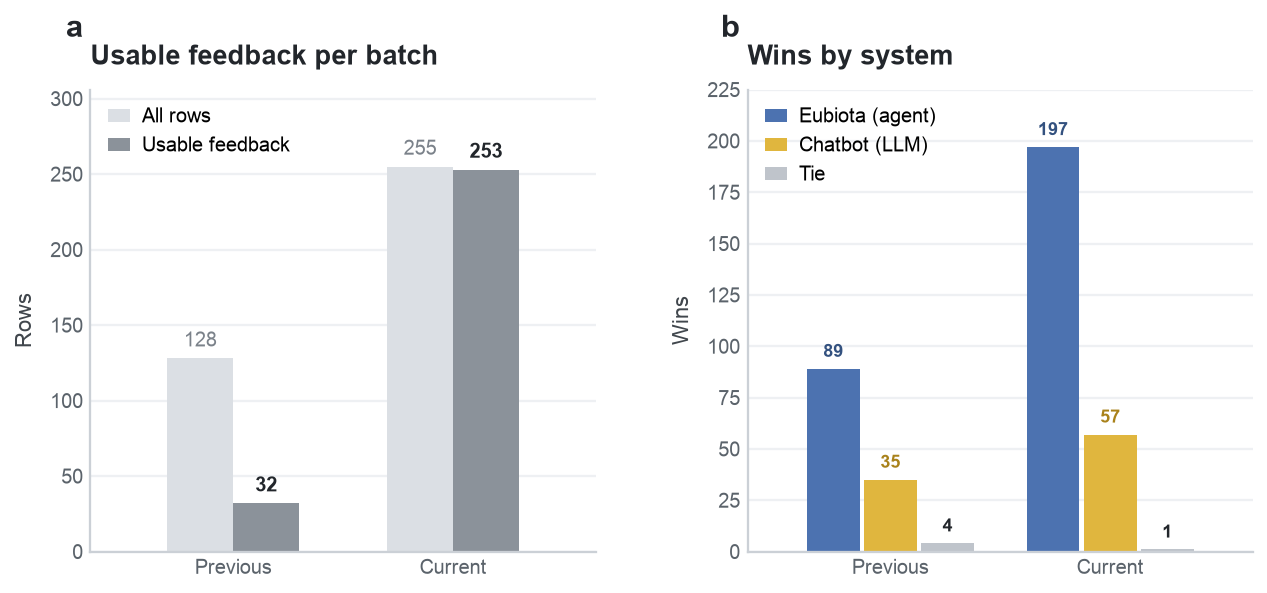

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0)); fig.subplots_adjust(wspace=0.30)
xs = np.arange(len(BATCH_ORDER))

ax = polish(axes[0]); w = 0.30
tot = [int((corpus.batch == b).sum()) for b in BATCH_ORDER]
usa = [int(((corpus.batch == b) & corpus.usable).sum()) for b in BATCH_ORDER]
ax.bar(xs - w/2, tot, w, color=NEUTRAL_L, label="All rows", zorder=2)
ax.bar(xs + w/2, usa, w, color=NEUTRAL_D, label="Usable feedback", zorder=2)
for x, t, u in zip(xs, tot, usa):
    ax.text(x - w/2, t + max(tot)*0.02, f"{t}", ha="center", va="bottom", fontsize=9.5, color=MUTE)
    ax.text(x + w/2, u + max(tot)*0.02, f"{u}", ha="center", va="bottom", fontsize=9.5, fontweight="bold", color=INK)
ax.set_xticks(xs); ax.set_xticklabels([b.capitalize() for b in BATCH_ORDER])
ax.set_ylabel("Rows"); ax.set_xlim(-0.65, 1.65); ax.set_ylim(0, max(tot)*1.2)
ax.legend(loc="upper left", handlelength=1.1, handletextpad=0.6)
titles(ax, "Usable feedback per batch"); panel(ax, "a")

ax = polish(axes[1]); w = 0.24
for i, s in enumerate(["agent", "llm", "tie"]):
    vals = [int(((corpus.batch == b) & (corpus.system == s)).sum()) for b in BATCH_ORDER]
    ax.bar(xs + (i-1)*(w+0.02), vals, w, color=SYS_COLORS[s], label=SYS_LABEL[s], zorder=2)
    for x, v in zip(xs, vals):
        if v: ax.text(x + (i-1)*(w+0.02), v + 4, f"{v}", ha="center", va="bottom",
                      fontsize=8.5, fontweight="bold", color=SYS_SHADE.get(s, INK))
ax.set_xticks(xs); ax.set_xticklabels([b.capitalize() for b in BATCH_ORDER])
ax.set_ylabel("Wins"); ax.set_xlim(-0.65, 1.65); ax.set_ylim(0, 225)
ax.legend(loc="upper left", handlelength=1.1, handletextpad=0.6)
titles(ax, "Wins by system"); panel(ax, "b")
savefig(fig, "fig1_dataset_flow"); plt.show()

### Figure 2 — Feedback availability
*Share of rows carrying a substantive comment. The previous batch is mostly blank ("-"); the current batch is richly annotated.*

saved figures/fig2_feedback_availability.svg


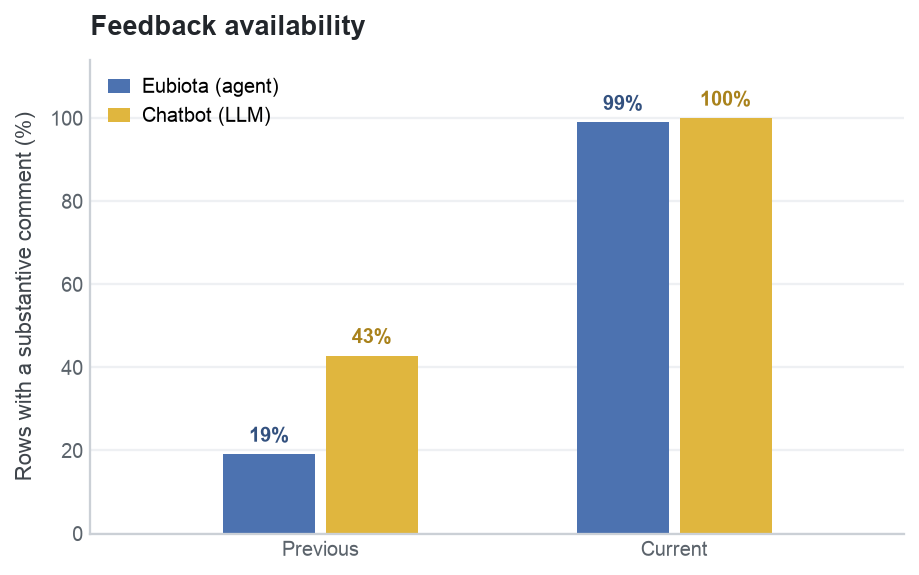

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.1)); polish(ax); xs = np.arange(len(BATCH_ORDER)); w = 0.26
for i, s in enumerate(["agent", "llm"]):
    pct = [100 * corpus[(corpus.batch == b) & (corpus.system == s)]["usable"].mean()
           if len(corpus[(corpus.batch == b) & (corpus.system == s)]) else 0 for b in BATCH_ORDER]
    ax.bar(xs + (i-0.5)*(w+0.03), pct, w, color=SYS_COLORS[s], label=SYS_LABEL[s], zorder=2)
    for x, v in zip(xs, pct):
        ax.text(x + (i-0.5)*(w+0.03), v + 2, f"{v:.0f}%", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold", color=SYS_SHADE[s])
ax.set_xticks(xs); ax.set_xticklabels([b.capitalize() for b in BATCH_ORDER])
ax.set_ylabel("Rows with a substantive comment (%)"); ax.set_xlim(-0.65, 1.65); ax.set_ylim(0, 114)
ax.legend(loc="upper left", handlelength=1.1, handletextpad=0.6)
titles(ax, "Feedback availability")
savefig(fig, "fig2_feedback_availability"); plt.show()

#### Figure 2b — Feedback availability (both batches combined)
*Same metric as Figure 2, but pooling the previous and current batches: the overall share of each system's rows that carry a substantive comment.*

saved figures/fig2b_availability_combined.svg


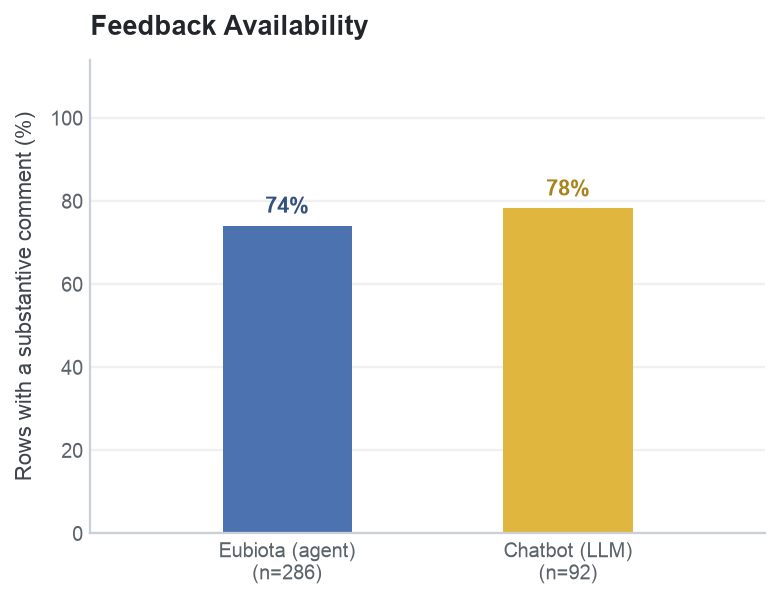

In [5]:
fig, ax = plt.subplots(figsize=(5.8, 4.1)); polish(ax)
for i, s in enumerate(["agent", "llm"]):
    sub = corpus[corpus.system == s]
    pct = 100 * sub["usable"].mean()
    ax.bar(i, pct, 0.46, color=SYS_COLORS[s], zorder=2)
    ax.text(i, pct + 2, f"{pct:.0f}%", ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=SYS_SHADE[s])
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{SYS_LABEL['agent']}\n(n={int((corpus.system=='agent').sum())})",
                    f"{SYS_LABEL['llm']}\n(n={int((corpus.system=='llm').sum())})"])
ax.set_ylabel("Rows with a substantive comment (%)"); ax.set_xlim(-0.7, 1.7); ax.set_ylim(0, 114)
titles(ax, "Feedback Availability")
savefig(fig, "fig2b_availability_combined"); plt.show()

### Figure 3 — Feedback length
*Words per usable comment by winner system, faceted by batch. Box = IQR, whisker = 10–90th pct, line = median, dots = individual comments.*

saved figures/fig3_feedback_length.svg


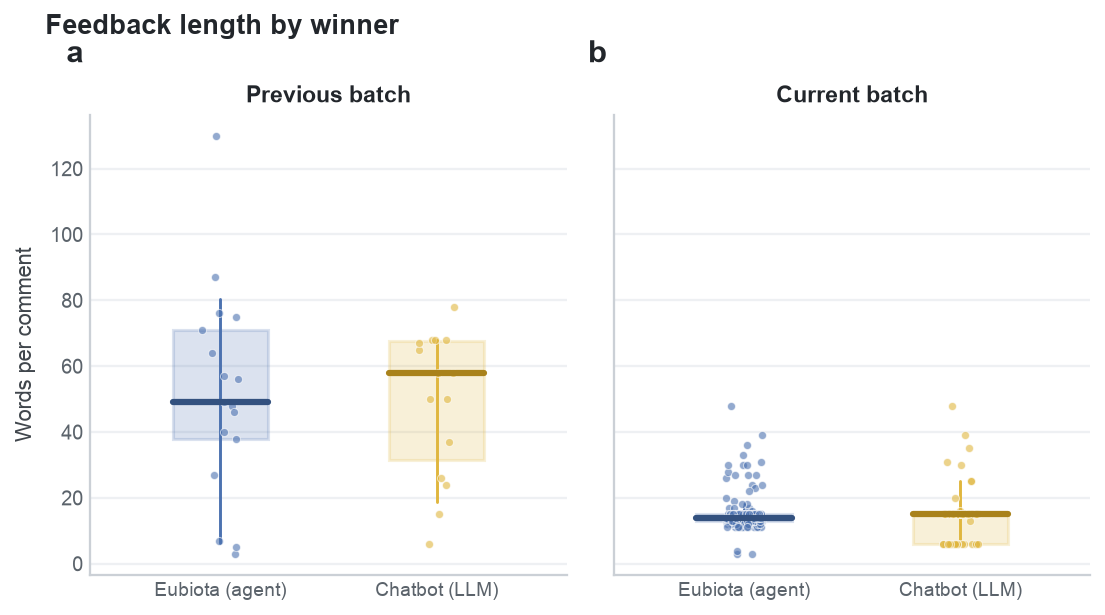

In [6]:
fig, axes = plt.subplots(1, len(BATCH_ORDER), figsize=(8.6, 4.2), sharey=True)
fig.subplots_adjust(wspace=0.10, top=0.84)
for k, (ax, b) in enumerate(zip(axes, BATCH_ORDER)):
    polish(ax)
    for i, s in enumerate(["agent", "llm"]):
        vals = corpus[(corpus.batch == b) & (corpus.system == s) & corpus.usable]["n_words"].values.astype(float)
        if not len(vals): continue
        c, cs = SYS_COLORS[s], SYS_SHADE[s]
        p10, q1, med, q3, p90 = np.percentile(vals, [10, 25, 50, 75, 90])
        ax.plot([i, i], [p10, p90], color=c, lw=1.4, zorder=2, solid_capstyle="round")
        ax.add_patch(Rectangle((i-0.22, q1), 0.44, q3-q1, facecolor=c, alpha=0.20, edgecolor=c, lw=1.5, zorder=3))
        ax.plot([i-0.22, i+0.22], [med, med], color=cs, lw=3.0, zorder=5, solid_capstyle="round")
        x = np.full(len(vals), i) + RNG.uniform(-0.085, 0.085, len(vals))
        ax.scatter(x, vals, s=15, color=c, alpha=0.6, edgecolor="white", linewidth=0.5, zorder=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels([SYS_LABEL["agent"], SYS_LABEL["llm"]], fontsize=9)
    ax.set_xlim(-0.6, 1.6); ax.set_title(f"{b.capitalize()} batch", fontsize=11, color=INK, loc="center", pad=6)
    panel(ax, "a" if k == 0 else "b")
axes[0].set_ylabel("Words per comment")
fig.suptitle("Feedback length by winner", x=0.09, y=1.0, ha="left", fontsize=13, fontweight="bold", color=INK)
savefig(fig, "fig3_feedback_length"); plt.show()

#### Figure 3b — Feedback length (both batches combined)
*Same as Figure 3, but pooling both batches into one comparison of comment length by winner system. Box = IQR, whisker = 10–90th pct, line = median, dots = individual comments.*

saved figures/fig3b_length_combined.svg


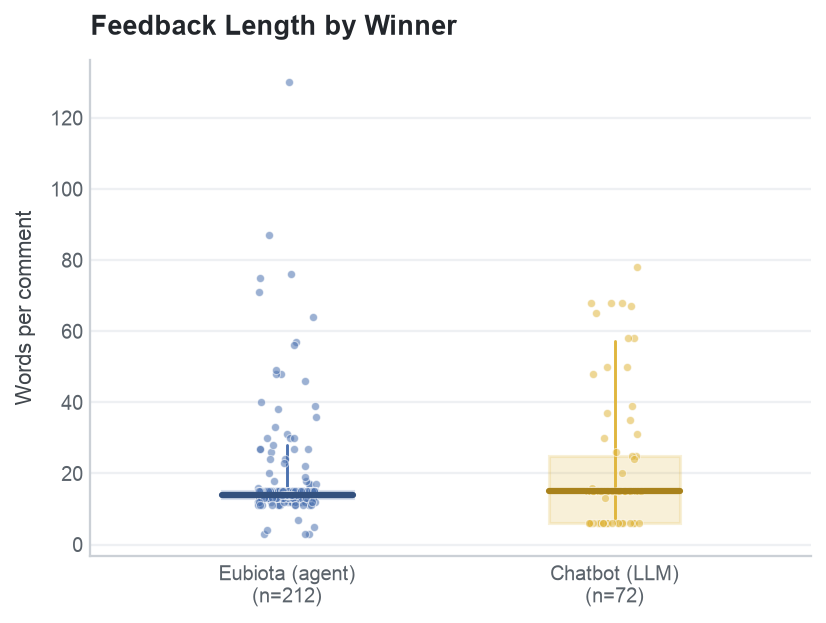

In [7]:
jr = np.random.default_rng(7)   # local jitter RNG so the global RNG (used by Fig 6) stays untouched
fig, ax = plt.subplots(figsize=(6.2, 4.3)); polish(ax)
for i, s in enumerate(["agent", "llm"]):
    vals = corpus[(corpus.system == s) & corpus.usable]["n_words"].values.astype(float)
    c, cs = SYS_COLORS[s], SYS_SHADE[s]
    p10, q1, med, q3, p90 = np.percentile(vals, [10, 25, 50, 75, 90])
    ax.plot([i, i], [p10, p90], color=c, lw=1.4, zorder=2, solid_capstyle="round")
    ax.add_patch(Rectangle((i-0.2, q1), 0.4, q3-q1, facecolor=c, alpha=0.20, edgecolor=c, lw=1.5, zorder=3))
    ax.plot([i-0.2, i+0.2], [med, med], color=cs, lw=3.0, zorder=5, solid_capstyle="round")
    x = np.full(len(vals), i) + jr.uniform(-0.09, 0.09, len(vals))
    ax.scatter(x, vals, s=15, color=c, alpha=0.55, edgecolor="white", linewidth=0.5, zorder=4)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{SYS_LABEL['agent']}\n(n={int(((corpus.system=='agent')&corpus.usable).sum())})",
                    f"{SYS_LABEL['llm']}\n(n={int(((corpus.system=='llm')&corpus.usable).sum())})"])
ax.set_xlim(-0.6, 1.6); ax.set_ylabel("Words per comment")
titles(ax, "Feedback Length by Winner")
savefig(fig, "fig3b_length_combined"); plt.show()

## 2. How the reasons were classified (methodology)

Every quality claim in the free text is sorted into one of **10 themes**, and — crucially — tagged
with **who the claim is about** and **whether it is positive or negative**. This lets us separate
*"the chosen answer is well-cited"* (a genuine strength of the winner) from *"the other answer had no
citations"* (a criticism of the loser), which otherwise look identical.

**Where the 10 themes came from.** They are a *hybrid*: (i) the study's own scoring rubric —
thoroughness, accuracy, actionability, transparency, use-of-resources — plus (ii) concepts that
recurred on a first read of the comments: specificity, conciseness/directness, clarity/structure,
unsupported/speculative claims, and retrieval/tool failure. **Every comment fell into at least one
theme — no "other" bucket was needed** (all 86 unique comments received ≥1 tag; the notebook checks
and prints this coverage below). A stricter second rater could add an "other" category, but none of
these comments required it.

**The 10 theme buckets**

| Theme | A claim lands here when it is about… |
|---|---|
| **Citations / evidence** | citations, PMIDs, sources, references, verifiability (or their absence). |
| **Transparency / trace** | showing the reasoning/search process, tool calls, execution log. |
| **Detail / thoroughness** | comprehensiveness, depth, robustness, covering many factors. |
| **Specificity** | naming specific entities (bacteria, proteins, studies) / numbers vs being generic. |
| **Conciseness / directness** | to-the-point, straightforward, avoids fluff / verbosity. |
| **Clarity / structure** | readability, formatting, headings, segmentation, key-findings organisation. |
| **Accuracy / correctness** | actually answering the question / correct mechanism (or being wrong / off-topic). |
| **Actionability / usefulness** | usable for research, customisable, concrete steps, would-use-again. |
| **Unsupported / speculative** | (fewer) unsupported or speculative claims. |
| **Retrieval / tool failure** | search/tools returning nothing, failed retrieval, dated / low-quality sources. |

**Classification procedure.** Each of the **86 unique comments** was read and coded by an **LLM
(Claude Opus 4.8)** into one or more tags of the form **`theme : target : valence`**, where

- **target** = `winner` (the response the reviewer *chose*) or `loser` (the *rejected* one), and
- **valence** = `positive` (a strength / praise) or `negative` (a weakness / criticism).

**A comment can carry several tags, including both praise and criticism** — e.g. *"A shows its full
trace and cites PMIDs, whereas B is unsourced"* → `transparency:winner:pos`, `citations:winner:pos`,
**and** `citations:loser:neg`. In this corpus **26 of 86 comments contain both** a winner-praise and a
loser-criticism, and all tags are retained.

**Technical specifics.** Coding is single-model (Claude Opus 4.8), stored per unique comment in an
auditable file, `data/feedback_theme_codes.csv`, regenerated by `code_themes.py` (which asserts the
unique-comment count so stale codes fail loudly). Tags are attached to *every evaluation that used
that comment*, so a preset used 30× counts 30× (the primary "weighted" lens). Ties and non-substantive
("-") comments are excluded from theme coding; the semantic map uses the unique strings.

In [8]:
import code_themes; code_themes.main()
codes = pd.read_csv(DATA / "feedback_theme_codes.csv")
ev = AL[["feedback", "system"]].copy(); ev["eval_id"] = np.arange(len(ev))
tagged = ev.merge(codes[["feedback", "theme", "target", "valence"]], on="feedback", how="left")
n_sys = ev["system"].value_counts().to_dict()
coverage = codes["feedback"].nunique() / AL["feedback"].nunique()
print(f"theme-code tags: {len(codes)} | evaluations per system: {n_sys}")
print(f"theme coverage: {coverage:.0%} of unique comments received >=1 theme (no 'other' bucket needed)")

def uniq_evals(df, theme): return df[df.theme == theme]["eval_id"].nunique()
def prevalence_wpos():
    out = {}
    for s in ["agent", "llm"]:
        d = tagged[(tagged.system == s) & (tagged.target == "winner") & (tagged.valence == "pos")]
        out[s] = {t: 100 * uniq_evals(d, t) / n_sys[s] for t in THEMES_ORDER}
    return out
prev_wpos = prevalence_wpos()

wrote data/feedback_theme_codes.csv: 240 tag-rows across 86 unique feedbacks
theme totals (winner-positive only):
theme
citation_evidence          44
transparency_trace         33
clarity_structure          27
detail_thoroughness        22
actionability              22
specificity                16
accuracy_correctness       15
conciseness_directness      9
unsupported_speculative     1
Name: count, dtype: int64
theme-code tags: 240 | evaluations per system: {'agent': 212, 'llm': 72}
theme coverage: 100% of unique comments received >=1 theme (no 'other' bucket needed)


### Figure 4 — What earns each system its wins
*Share of winning evaluations whose comment praises the chosen answer for each theme (winner-positive tags). Retrieval/tool failure is never a reason to praise a winner, so it reads as 0 here; its data appears as criticism in Figure 5 and in the co-occurrence map (Figure 7).*

saved figures/fig4_theme_frequencies.svg


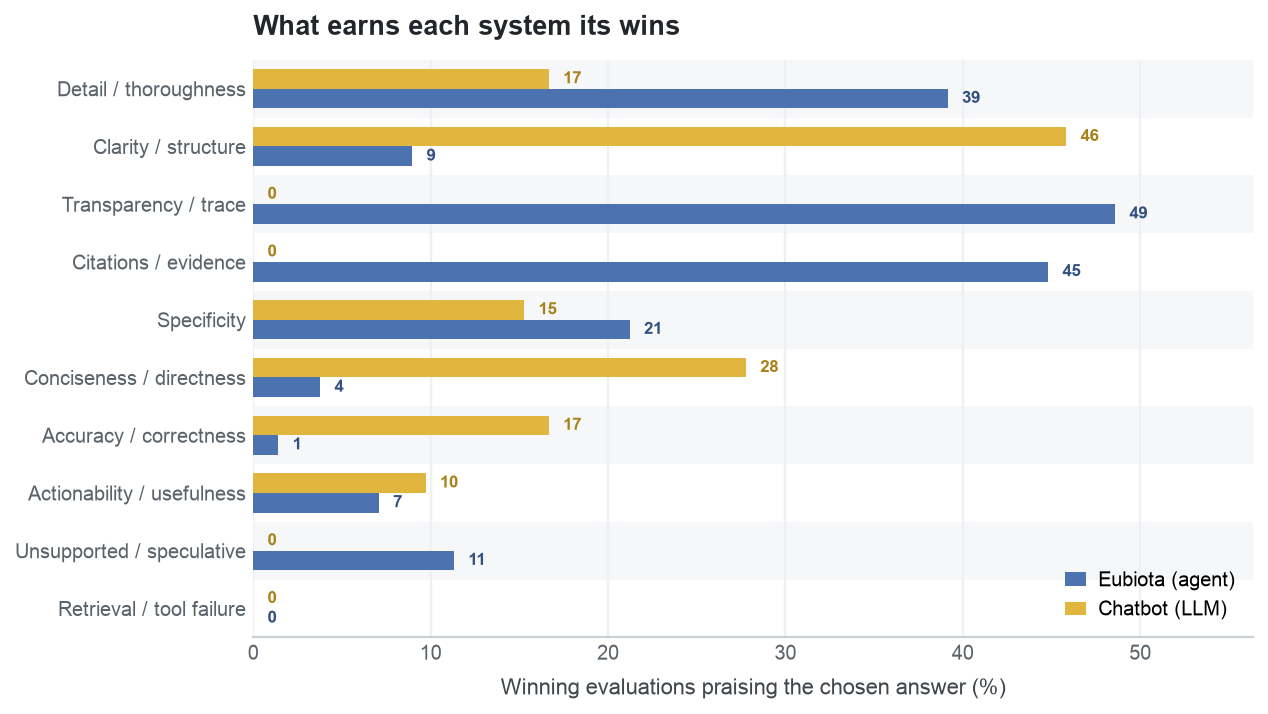

In [9]:
order = sorted(THEMES_ORDER, key=lambda t: -(prev_wpos["agent"][t] + prev_wpos["llm"][t]))
fig, ax = plt.subplots(figsize=(8.6, 5.0)); polish(ax, left=False, grid="x")
ys = np.arange(len(order)); h = 0.34
zebra(ax, len(order))
for i, s in enumerate(["agent", "llm"]):
    vals = [prev_wpos[s][t] for t in order]
    ax.barh(ys + (0.5-i)*h, vals, h, color=SYS_COLORS[s], label=SYS_LABEL[s], zorder=3)
    for y, v in zip(ys + (0.5-i)*h, vals):
        ax.text(v + 0.8, y, f"{v:.0f}", va="center", ha="left", fontsize=8, color=SYS_SHADE[s], fontweight="bold")
ax.set_yticks(ys); ax.set_yticklabels([THEME_LABEL[t] for t in order]); ax.invert_yaxis()
ax.set_ylim(len(order)-0.5, -0.5)
ax.set_xlabel("Winning evaluations praising the chosen answer (%)")
ax.set_xlim(0, max(max(prev_wpos["agent"].values()), max(prev_wpos["llm"].values()))*1.16)
ax.legend(loc="lower right", handlelength=1.1, handletextpad=0.6)
titles(ax, "What earns each system its wins")
savefig(fig, "fig4_theme_frequencies"); plt.show()

### Figure 5 — Praise of the winner vs. criticism of the loser
*Each claim is coded by target (chosen winner / rejected loser) and valence; a single comment can appear on both sides. Colour = which system won. This separates "our answer is well-sourced" from "the other answer had no sources".*

saved figures/fig5_target_attribution.svg


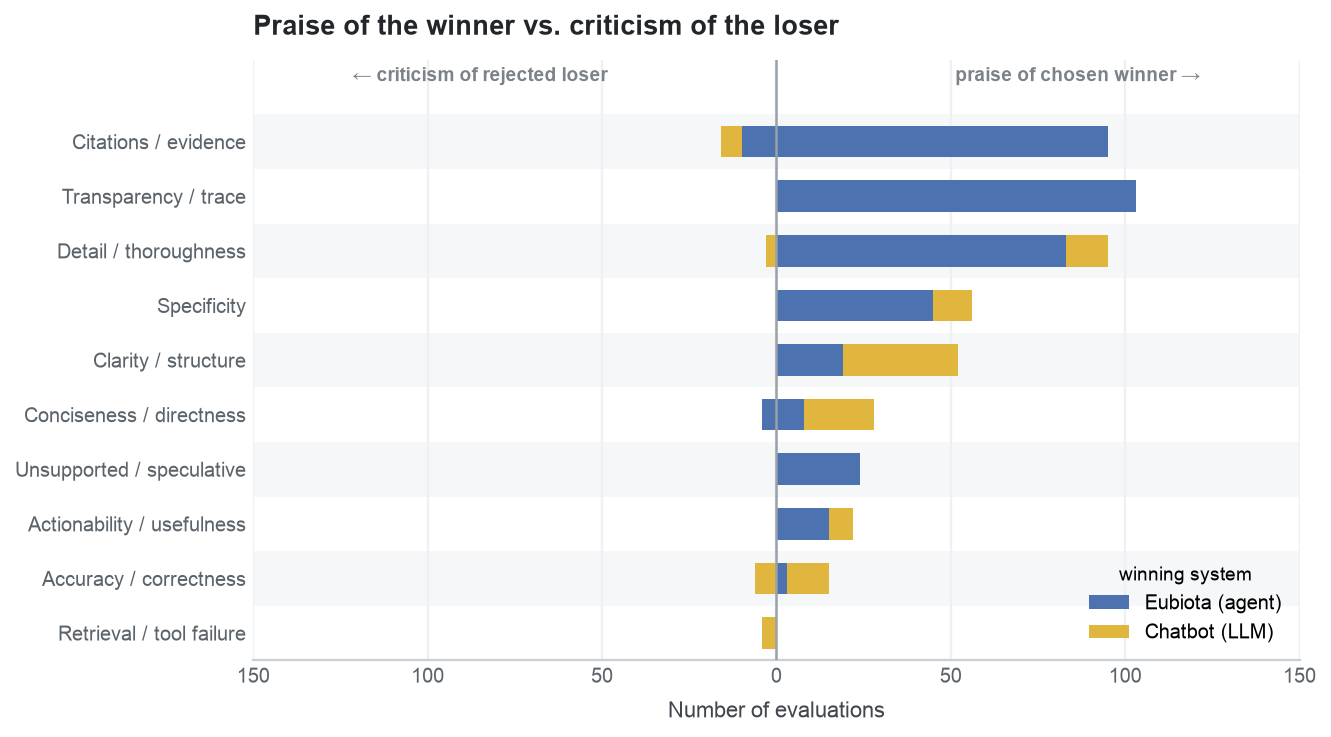

In [10]:
def counts(target, valence, system):
    d = tagged[(tagged.target==target) & (tagged.valence==valence) & (tagged.system==system)]
    return {t: uniq_evals(d, t) for t in THEMES_ORDER}
pa, pl = counts("winner","pos","agent"), counts("winner","pos","llm")
ca, cl = counts("loser","neg","agent"),  counts("loser","neg","llm")
order = sorted(THEMES_ORDER, key=lambda t: -((pa[t]+pl[t]) + (ca[t]+cl[t])))
ys = np.arange(len(order)); HB = 0.58
fig, ax = plt.subplots(figsize=(9.0, 5.2)); polish(ax, left=False, grid="x")
zebra(ax, len(order))
ax.barh(ys, [pa[t] for t in order], HB, color=EUB, zorder=3, label=SYS_LABEL["agent"])
ax.barh(ys, [pl[t] for t in order], HB, left=[pa[t] for t in order], color=LLM, zorder=3, label=SYS_LABEL["llm"])
ax.barh(ys, [-ca[t] for t in order], HB, color=EUB, zorder=3)
ax.barh(ys, [-cl[t] for t in order], HB, left=[-ca[t] for t in order], color=LLM, zorder=3)
ax.axvline(0, color="#9AA1A9", lw=1.2, zorder=4)
mx = max(max(pa[t]+pl[t] for t in order), max(ca[t]+cl[t] for t in order))
ax.set_xlim(-mx*1.22, mx*1.22); ax.set_yticks(ys); ax.set_yticklabels([THEME_LABEL[t] for t in order])
ax.invert_yaxis(); ax.set_ylim(len(order)-0.5, -1.5)
ax.set_xticks(ax.get_xticks()); ax.set_xticklabels([abs(int(x)) for x in ax.get_xticks()])
ax.set_xlabel("Number of evaluations")
ax.text(-mx*1.18, -1.2, "← criticism of rejected loser", color=MUTE, fontsize=9, ha="left", va="center", fontweight="bold")
ax.text( mx*1.18, -1.2, "praise of chosen winner →", color=MUTE, fontsize=9, ha="right", va="center", fontweight="bold")
ax.legend(loc="lower right", title="winning system", title_fontsize=9)
titles(ax, "Praise of the winner vs. criticism of the loser")
savefig(fig, "fig5_target_attribution"); plt.show()

### Figure 6 — Reasons that distinguish the two systems' wins  *(forest plot)*
*log2 fold-change of theme prevalence (Eubiota-win vs Chatbot-win) with bootstrap 95% CIs. **Exploratory** — the Chatbot-win sample is small.*

saved figures/fig6_theme_enrichment.svg


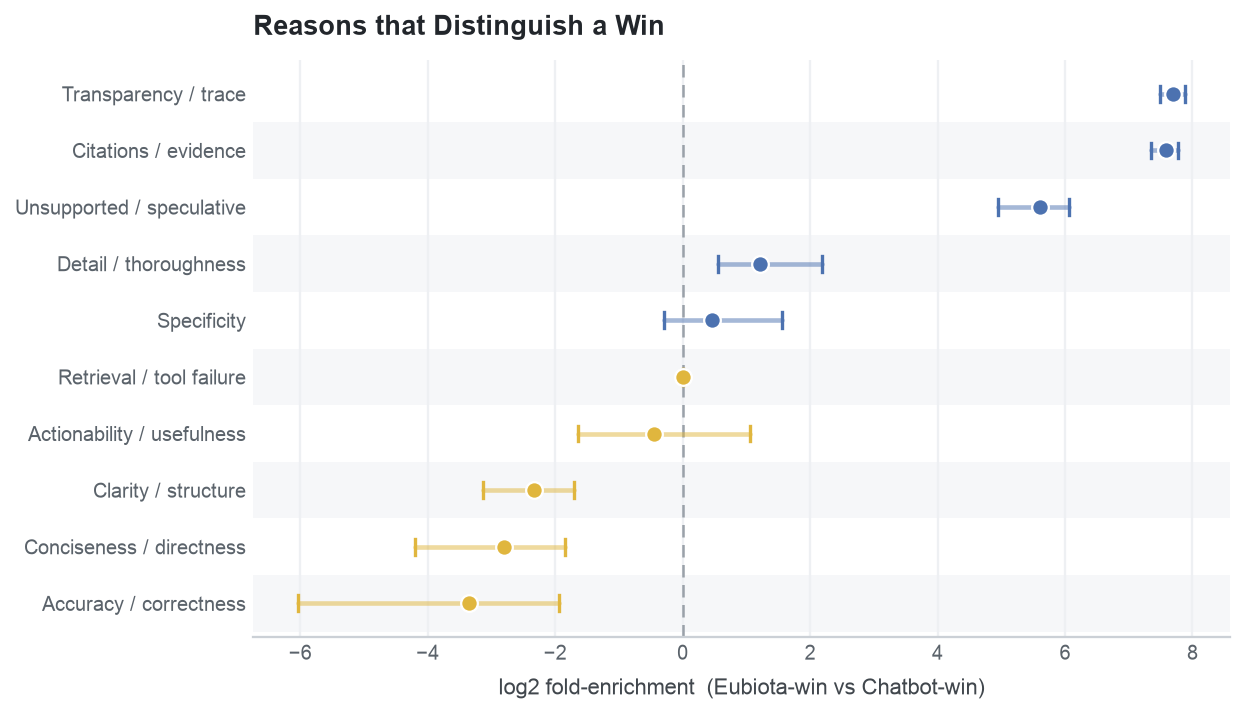

In [11]:
def membership(system):
    ids = ev[ev.system == system]["eval_id"].values
    have = tagged[(tagged.system==system) & (tagged.target=="winner") & (tagged.valence=="pos")]
    sets = {t: set(have[have.theme==t]["eval_id"]) for t in THEMES_ORDER}
    # boolean matrix: rows = themes, cols = this system's evaluations
    B = np.array([[1.0 if i in sets[t] else 0.0 for i in ids] for t in THEMES_ORDER])
    return B
Ba, Bl = membership("agent"), membership("llm")          # (10, n_agent), (10, n_llm)
EPS = 0.5 / max(Ba.shape[1], Bl.shape[1])
pa, pl = Ba.mean(1), Bl.mean(1)
log2fc = np.log2((pa + EPS) / (pl + EPS))
# vectorised bootstrap: resample columns, recompute per-theme prevalence
na, nl = Ba.shape[1], Bl.shape[1]
boot_a = np.stack([Ba[:, RNG.integers(0, na, na)].mean(1) for _ in range(N_BOOT)])
boot_l = np.stack([Bl[:, RNG.integers(0, nl, nl)].mean(1) for _ in range(N_BOOT)])
boot_fc = np.log2((boot_a + EPS) / (boot_l + EPS))
lo, hi = np.percentile(boot_fc, 2.5, axis=0), np.percentile(boot_fc, 97.5, axis=0)
enr = (pd.DataFrame({"theme": THEMES_ORDER, "log2fc": log2fc, "lo": lo, "hi": hi})
       .sort_values("log2fc").reset_index(drop=True))
fig, ax = plt.subplots(figsize=(8.4, 5.0)); polish(ax, left=False, grid="x")
ys = np.arange(len(enr)); zebra(ax, len(enr))
ax.axvline(0, color="#9AA1A9", lw=1.2, ls=(0,(5,3)), zorder=2)
for y, (_, r) in zip(ys, enr.iterrows()):
    c = EUB if r.log2fc > 0 else LLM
    ax.plot([r.lo, r.hi], [y, y], color=c, lw=2.2, alpha=0.5, solid_capstyle="round", zorder=3)
    ax.plot([r.lo, r.lo], [y-0.14, y+0.14], color=c, lw=1.6, zorder=3)
    ax.plot([r.hi, r.hi], [y-0.14, y+0.14], color=c, lw=1.6, zorder=3)
    ax.scatter(r.log2fc, y, color=c, s=64, zorder=4, edgecolor="white", linewidth=1.1)
ax.set_yticks(ys); ax.set_yticklabels([THEME_LABEL[t] for t in enr["theme"]]); ax.set_ylim(-0.6, len(enr)-0.4)
ax.set_xlabel("log2 fold-enrichment  (Eubiota-win vs Chatbot-win)")
xl = ax.get_xlim()

titles(ax, "Reasons that Distinguish a Win")
savefig(fig, "fig6_theme_enrichment"); plt.show()

### Figure 7 — Which reasons are raised together
*Row-normalised co-mention of themes within a comment (any polarity), weighted by how often each comment was used. Read a cell as P(column theme | row theme).*

saved figures/fig7_cooccurrence.svg


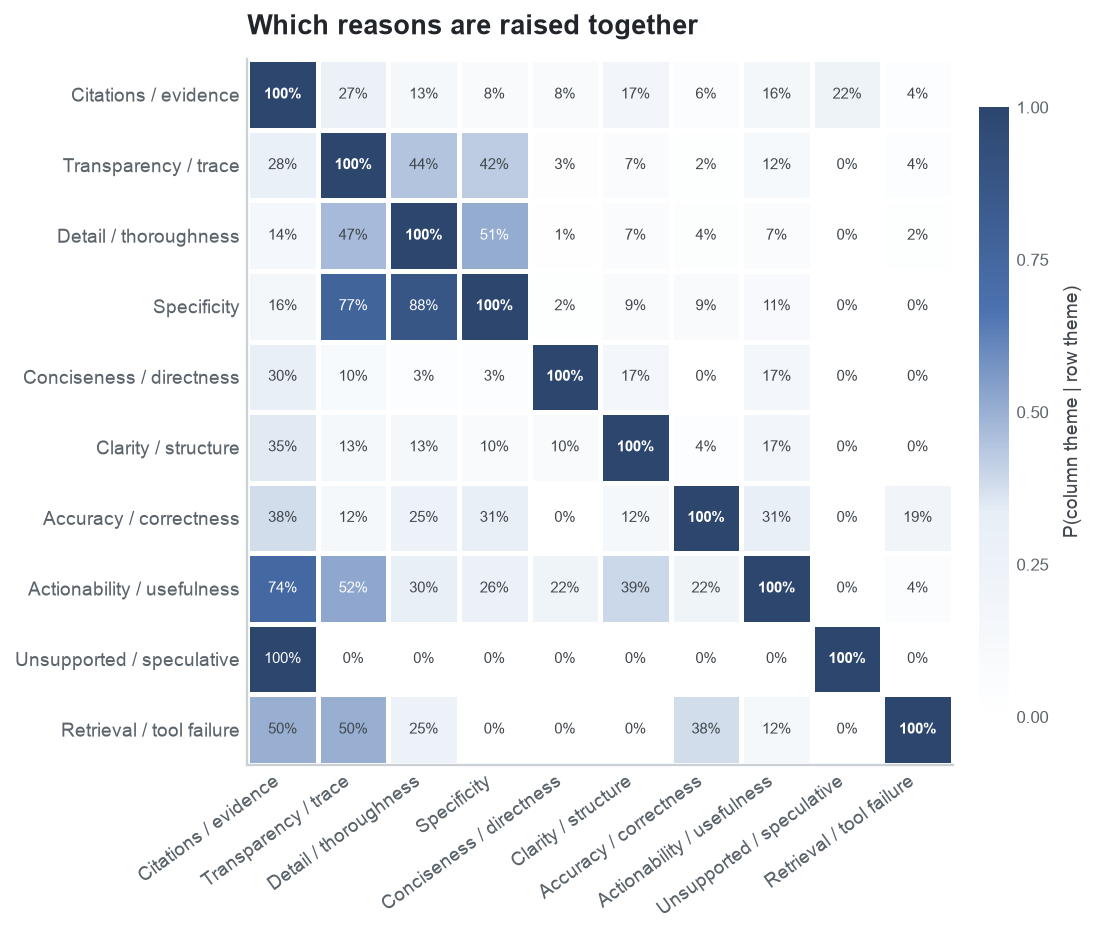

In [12]:
themes_by_fb = codes.groupby("feedback")["theme"].apply(set)
usage = AL.groupby("feedback").size()
idx = {t:i for i,t in enumerate(THEMES_ORDER)}
M = np.zeros((len(THEMES_ORDER), len(THEMES_ORDER)))
for fb, ts in themes_by_fb.items():
    w = usage.get(fb, 1)
    for a in ts:
        for b in ts: M[idx[a], idx[b]] += w
diag = np.diag(M).copy(); Mn = M / np.where(diag[:,None]==0, 1, diag[:,None])
fig, ax = plt.subplots(figsize=(7.6, 6.6)); ax.grid(False)
im = ax.imshow(Mn, cmap=SEQ_BLUE, vmin=0, vmax=1)
ax.set_xticks(np.arange(-.5, len(THEMES_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(THEMES_ORDER), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2.4); ax.tick_params(which="minor", length=0)
labs = [THEME_LABEL[t] for t in THEMES_ORDER]
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=36, ha="right", fontsize=9); ax.tick_params(length=0)
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=9)
for i in range(len(labs)):
    for j in range(len(labs)):
        if diag[i] > 0:
            ax.text(j, i, f"{Mn[i,j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if Mn[i,j] > 0.5 else "#41474D", fontweight=("bold" if i==j else "normal"))
cb = fig.colorbar(im, ax=ax, shrink=0.78, pad=0.03, ticks=[0,0.25,0.5,0.75,1.0])
cb.outline.set_visible(False); cb.set_label("P(column theme | row theme)", fontsize=9); cb.ax.tick_params(length=0, labelsize=8)
titles(ax, "Which reasons are raised together")
fig.tight_layout(); savefig(fig, "fig7_cooccurrence"); plt.show()

### Figure 8 — Most frequent words in the reasons
*Word size = frequency across all winning evaluations for that system (exported as vector SVG).*

saved figures/fig8_wordclouds.svg


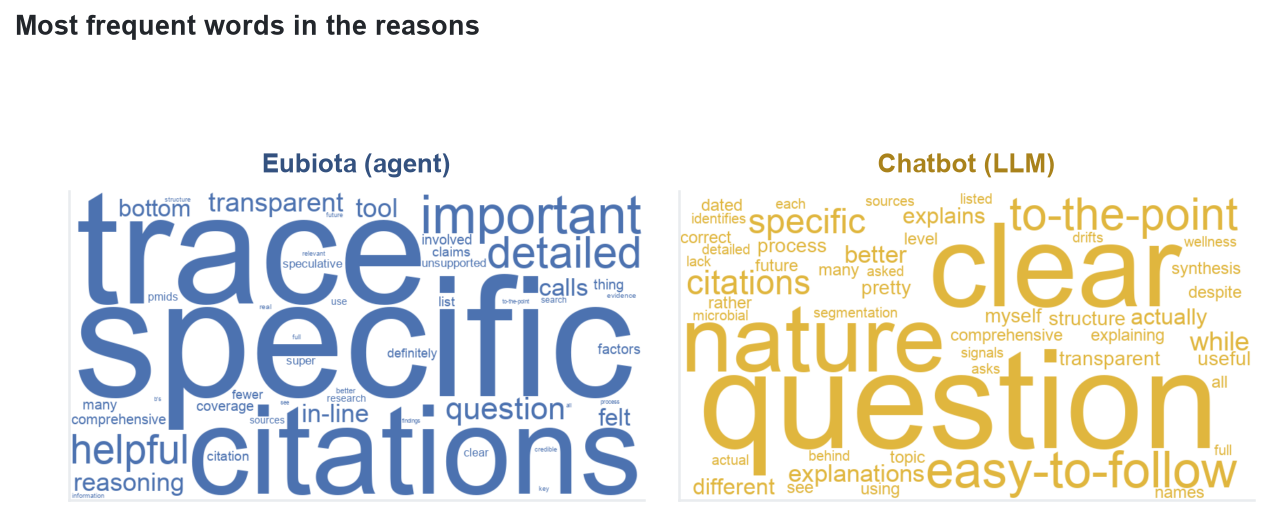

In [13]:
from wordcloud import WordCloud
STOP = set("""a an the this that these those is are was were be been being it its it's system systems
response responses answer answers model output i you we they he she of to in on for with and or but so
because as at by from more most much very really like liked also both one two which what when how why
than then them their there here has have had do does did can could would should i'd i'll it into gives
give provides provide shows show system's lot lots overall well good great about get go got if no not""".split())
arial = next((f for f in ["/System/Library/Fonts/Supplemental/Arial.ttf", "/Library/Fonts/Arial.ttf"] if Path(f).exists()), None)
def word_freqs(system):
    from collections import Counter
    c = Counter()
    for fb in AL[AL.system == system]["feedback"]:
        for w in re.findall(r"[a-zA-Z][a-zA-Z'\-]+", fb.lower()):
            if w not in STOP and len(w) > 2: c[w] += 1
    return c
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2)); fig.subplots_adjust(wspace=0.06)
for ax, s in zip(axes, ["agent", "llm"]):
    wc = WordCloud(width=820, height=440, background_color="white", font_path=arial, prefer_horizontal=1.0,
                   color_func=lambda *a, c=SYS_COLORS[s], **k: c, max_words=50, relative_scaling=0.55,
                   margin=4, random_state=0).generate_from_frequencies(word_freqs(s))
    ax.imshow(wc, interpolation="bilinear"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(HAIR); sp.set_linewidth(1.2)
    ax.set_title(SYS_LABEL[s], fontsize=12.5, fontweight="bold", color=SYS_SHADE[s], pad=9)
    (FIG / f"fig8_wordcloud_{s}.svg").write_text(wc.to_svg(embed_font=True))
fig.suptitle("Most frequent words in the reasons", x=0.09, y=1.02, ha="left", fontsize=13, fontweight="bold", color=INK)
savefig(fig, "fig8_wordclouds"); plt.show()

### Figure 9 — Semantic map of the reasons
*Each bubble is one unique comment; nearby bubbles use semantically similar wording; bubble size = how many evaluations used it; colour = winning system. The most-used comments are labelled so the space is interpretable.*

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

saved figures/fig9_semantic_map.svg


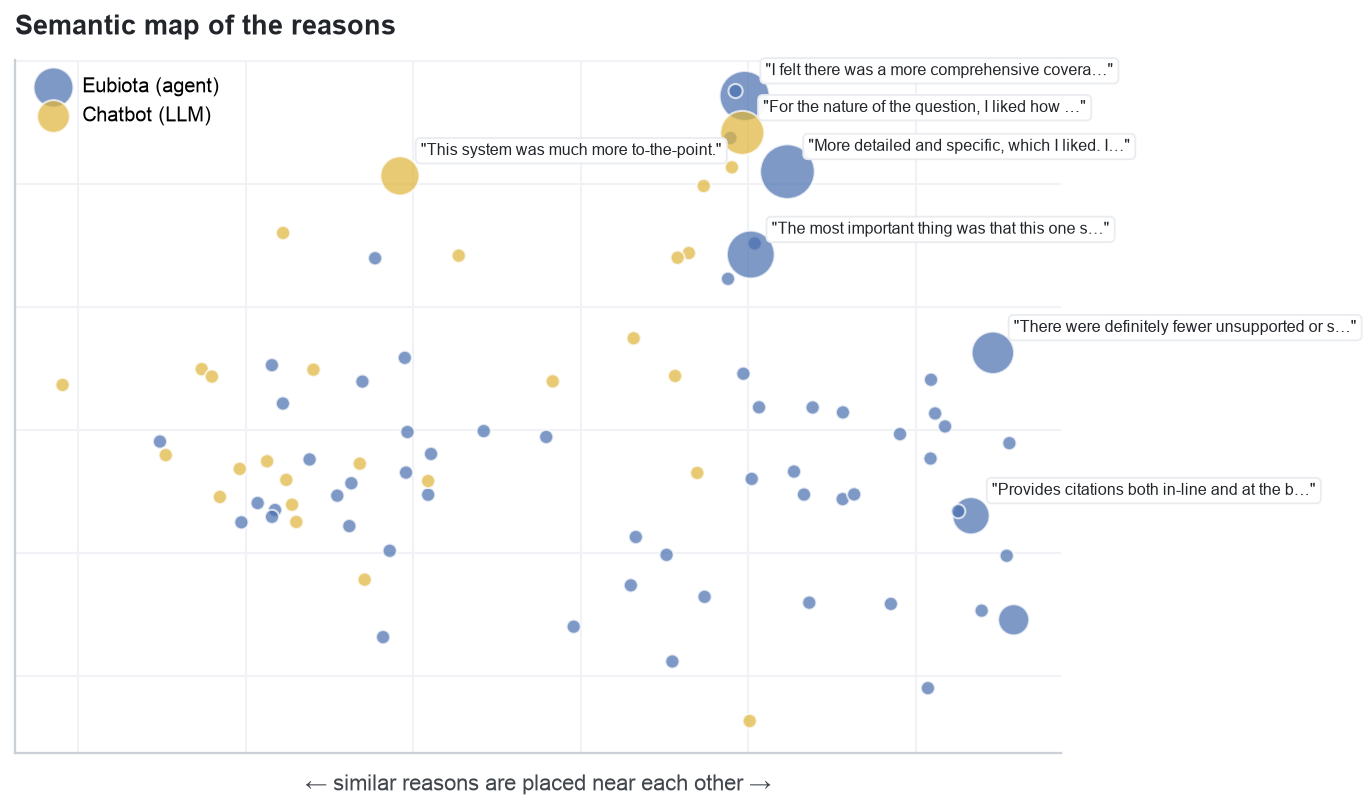

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
uniq = AL.groupby("feedback").agg(n=("feedback","size"),
        system=("system", lambda s: s.value_counts().index[0])).reset_index()
model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(uniq["feedback"].tolist(), normalize_embeddings=True, show_progress_bar=False)
xy = PCA(n_components=2, random_state=0).fit_transform(emb)
uniq["x"], uniq["y"] = xy[:,0], xy[:,1]
fig, ax = plt.subplots(figsize=(9.0, 6.0)); polish(ax)
ax.grid(True, axis="both", color="#F0F2F5", lw=1.0)
for s in ["agent", "llm"]:
    m = uniq.system == s
    ax.scatter(uniq.x[m], uniq.y[m], s=30 + 16*uniq.n[m], color=SYS_COLORS[s], alpha=0.72,
               edgecolor="white", linewidth=1.0, label=SYS_LABEL[s], zorder=2)
for _, r in uniq.sort_values("n", ascending=False).head(7).iterrows():
    gist = re.sub(r"\s+", " ", r["feedback"])[:44] + ("…" if len(r["feedback"]) > 44 else "")
    ax.annotate(f'"{gist}"', (r.x, r.y), fontsize=7.6, color=INK, xytext=(10, 10), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.32", fc="white", ec=HAIR, lw=0.9, alpha=0.95), zorder=3)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_ylabel("")
ax.set_xlabel("← similar reasons are placed near each other →")
ax.legend(loc="upper left", handletextpad=0.5)
titles(ax, "Semantic map of the reasons")
savefig(fig, "fig9_semantic_map"); plt.show()

## 3. LLM-win "upset" deep-dive

Eubiota wins most comparisons, so the **Chatbot wins are the most informative cases**: when does the
plain chatbot beat the deep-research agent, and why?

### Figure 10 — Why the chatbot beat Eubiota
*The reasons praised in the Chatbot-win evaluations — clarity and directness, not evidence.*

saved figures/fig10_llm_win_reasons.svg


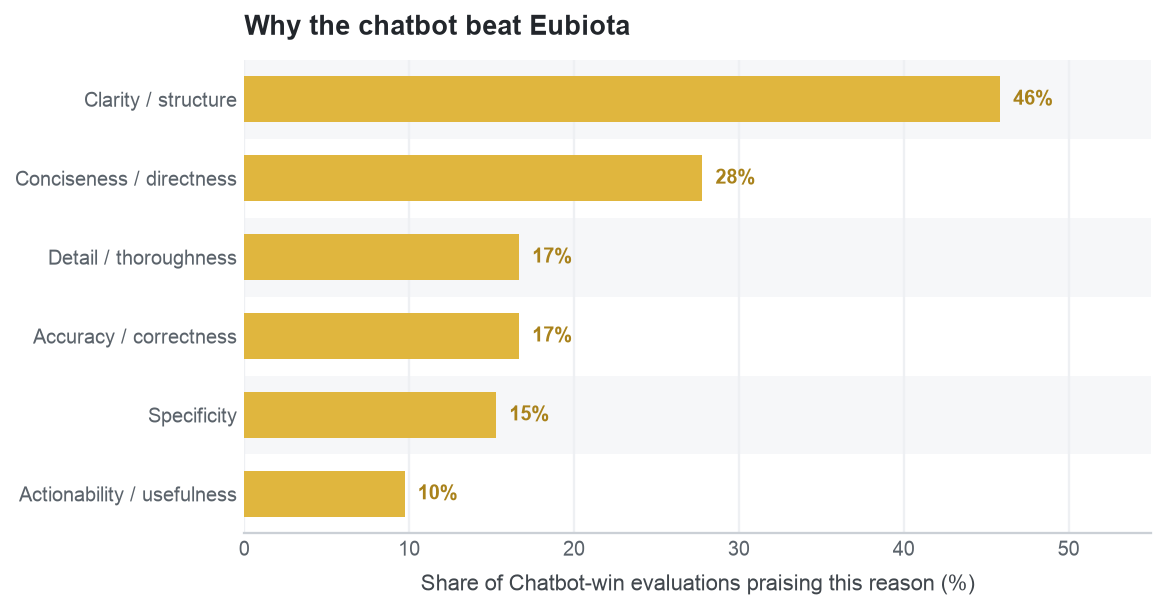


Representative Chatbot-win reasons (longest, most-specific unique comments):

 • I like system A here. It is a clean detailed explanation that is more specific/useful than system B. I could see myself using system A when thinking about my research but the one downside to its response is the lack of citations or transparency in the response synthesis process. However, overall, sy 

 • While system B is definitely more transparent, system A explains exact mechanisms like how A can bind with mTORC1. System B's response is relatively surface level and the citations are there but they are from fitness blogs and YouTube, which is not ideal for a molecular-level question. System A has  

 • I would say system A here. System B is definitely more transparent in the answer synthesis process and it has citations listed, but the citations are pretty dated. System A has clear explanations and I like the segmentation of the response into different points. System A offers to refine based on th 

 • 

In [15]:
llm_wpos = dict(sorted({t: prev_wpos["llm"][t] for t in THEMES_ORDER if prev_wpos["llm"][t] > 0}.items(),
                       key=lambda kv: -kv[1]))
fig, ax = plt.subplots(figsize=(7.8, 4.1)); polish(ax, left=False, grid="x")
ys = np.arange(len(llm_wpos)); zebra(ax, len(llm_wpos))
ax.barh(ys, list(llm_wpos.values()), 0.58, color=LLM, zorder=3)
for y, v in zip(ys, llm_wpos.values()):
    ax.text(v + 0.8, y, f"{v:.0f}%", va="center", ha="left", fontsize=9.5, fontweight="bold", color=LLM_D)
ax.set_yticks(ys); ax.set_yticklabels([THEME_LABEL[t] for t in llm_wpos]); ax.invert_yaxis()
ax.set_ylim(len(llm_wpos)-0.5, -0.5)
ax.set_xlabel("Share of Chatbot-win evaluations praising this reason (%)"); ax.set_xlim(0, max(llm_wpos.values())*1.2)
titles(ax, "Why the chatbot beat Eubiota")
savefig(fig, "fig10_llm_win_reasons"); plt.show()

print("\nRepresentative Chatbot-win reasons (longest, most-specific unique comments):\n")
llm_u = AL[AL.system=="llm"].drop_duplicates("feedback").copy(); llm_u["L"] = llm_u["feedback"].str.len()
for fb in llm_u.sort_values("L", ascending=False)["feedback"].head(5):
    print(" •", fb[:300], "\n")

## 4. Representative quote gallery

One real, verbatim comment per top theme (per system where available) — so every bar is grounded in
the reviewers' own words and the LLM coding can be spot-checked.

In [16]:
def example_for(theme, system):
    ids = tagged[(tagged.system==system)&(tagged.theme==theme)&(tagged.target=="winner")&(tagged.valence=="pos")]["eval_id"]
    if not len(ids): return None
    fbs = ev.loc[ev.eval_id.isin(ids), "feedback"].unique()
    return sorted(fbs, key=lambda s: abs(len(s) - 150))[0]
print("REPRESENTATIVE QUOTES BY THEME\n" + "="*70)
for t in [t for t in THEMES_ORDER if prev_wpos["agent"][t] + prev_wpos["llm"][t] > 0][:8]:
    print(f"\n### {THEME_LABEL[t]}")
    for s in ["agent", "llm"]:
        ex = example_for(t, s)
        if ex: print(f"  [{SYS_LABEL[s]}] “{ex[:220]}”")

REPRESENTATIVE QUOTES BY THEME

### Citations / evidence
  [Eubiota (agent)] “Would appreciate if the claims were a bit more specific for system B but everything is transparent and I like all the in-line citations to PMIDs.”

### Transparency / trace
  [Eubiota (agent)] “Would appreciate if the claims were a bit more specific for system B but everything is transparent and I like all the in-line citations to PMIDs.”

### Detail / thoroughness
  [Eubiota (agent)] “There are 10 real PMIDs and in-line citations are provided throughout the response. The response overall is very robust and specific as well.”
  [Chatbot (LLM)] “A actually explains the bidirectionality the question asks about and provides more rich information despite its lack of sources listed.”

### Specificity
  [Eubiota (agent)] “There are 10 real PMIDs and in-line citations are provided throughout the response. The response overall is very robust and specific as well.”
  [Chatbot (LLM)] “Though A shows its full trace and 

## Summary — what the feedback says

In [17]:
L = ["="*74, "WHAT DRIVES THE PICK (LLM-coded feedback themes)", "="*74,
     f"\nn = {len(AL)} usable Eubiota/Chatbot evaluations ({AL.feedback.nunique()} unique comments); "
     f"Eubiota-win {n_sys['agent']}, Chatbot-win {n_sys['llm']}. Ties kept in data, excluded here."]
L.append("\nEubiota (agent) wins are praised most for:")
for t in sorted(THEMES_ORDER, key=lambda t: -prev_wpos["agent"][t])[:4]:
    L.append(f"   - {THEME_LABEL[t]:26s} {prev_wpos['agent'][t]:.0f}% of Eubiota-win evals")
L.append("\nChatbot (LLM) wins are praised most for:")
for t in sorted(THEMES_ORDER, key=lambda t: -prev_wpos["llm"][t])[:4]:
    L.append(f"   - {THEME_LABEL[t]:26s} {prev_wpos['llm'][t]:.0f}% of Chatbot-win evals")
L.append(f"\nMost Eubiota-characteristic: {THEME_LABEL[enr.iloc[-1]['theme']]} (log2fc {enr.iloc[-1]['log2fc']:+.1f}).")
L.append(f"Most Chatbot-characteristic:  {THEME_LABEL[enr.iloc[0]['theme']]} (log2fc {enr.iloc[0]['log2fc']:+.1f}).")
L.append("\nCaveats: preset-heavy free text (86 unique of "
         f"{len(AL)}); Chatbot-win n small so enrichment is exploratory; single-model (Claude Opus 4.8) "
         "theme coding — audit via data/feedback_theme_codes.csv and the quote gallery.")
print("\n".join(L))

WHAT DRIVES THE PICK (LLM-coded feedback themes)

n = 284 usable Eubiota/Chatbot evaluations (86 unique comments); Eubiota-win 212, Chatbot-win 72. Ties kept in data, excluded here.

Eubiota (agent) wins are praised most for:
   - Transparency / trace       49% of Eubiota-win evals
   - Citations / evidence       45% of Eubiota-win evals
   - Detail / thoroughness      39% of Eubiota-win evals
   - Specificity                21% of Eubiota-win evals

Chatbot (LLM) wins are praised most for:
   - Clarity / structure        46% of Chatbot-win evals
   - Conciseness / directness   28% of Chatbot-win evals
   - Detail / thoroughness      17% of Chatbot-win evals
   - Accuracy / correctness     17% of Chatbot-win evals

Most Eubiota-characteristic: Transparency / trace (log2fc +7.7).
Most Chatbot-characteristic:  Accuracy / correctness (log2fc -3.4).

Caveats: preset-heavy free text (86 unique of 284); Chatbot-win n small so enrichment is exploratory; single-model (Claude Opus 4.8) theme co